# Taller 1 - Clasificación: recurrencia de cáncer tiroideo diferenciado

**Dataset:** *Thyroid Disease Data* (Kaggle) - 383 registros clínicos de pacientes con
cáncer tiroideo diferenciado, 17 variables.

**Target:** `Recurred` (`Yes` = 1 recurrencia, `No` = 0).

## Fase 1 - EDA, limpieza y preprocesamiento

### 1. Problema de salud, dataset y variable objetivo

Aunque el título de la fuente menciona "enfermedad tiroidea", el CSV no predice un
diagnóstico inicial: cada fila es un paciente con cáncer tiroideo diferenciado ya
tratado y el target indica si la enfermedad **recurrió**. Es un problema de pronóstico de
seguimiento oncológico.

- **Problema de salud:** identificar, al momento del diagnóstico y de la planificación
  del tratamiento inicial, qué pacientes tienen mayor riesgo de recurrencia para
  asignarles vigilancia más estrecha (ecografías, tiroglobulina, consultas).
- **Variable objetivo:** `Recurred` (`Yes` = recurrencia). Es un problema de
  **clasificación binaria**.
- **Clase positiva:** `Yes`. Un **falso negativo** (paciente que sí recurrirá y se
  clasifica como "No") puede perder vigilancia oportuna; un **falso positivo** implica
  pruebas y seguimiento innecesarios. Por el contexto clínico, el falso negativo es más
  costoso, por lo que se priorizará **Recall** sin aceptar una Precision que genere
  demasiadas alertas inútiles.
- **Alcance:** dataset pequeño (383 filas), retrospectivo y sin marca temporal por
  paciente. El modelo es educativo; no es una herramienta de decisión médica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

candidatos = [Path("data/raw/thyroid/Thyroid_Diff.csv"), Path("../data/raw/thyroid/Thyroid_Diff.csv")]
DATA_PATH = next(p for p in candidatos if p.exists())
print("Archivo (relativo a la raíz del repo):", DATA_PATH)

Archivo (relativo a la raíz del repo): data\raw\thyroid\Thyroid_Diff.csv


### 2. Carga, estructura y diccionario de datos

In [2]:
df_raw = pd.read_csv(DATA_PATH)
display(df_raw.head(3))
display(df_raw.tail(3))
print("shape:", df_raw.shape)
df_raw.info()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


shape: (383, 17)
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Re

El dataset tiene 383 filas y 17 columnas: 16 categóricas y una numérica (`Age`). El
diccionario de datos documenta el significado clínico y el uso previsto. Se conservan
los nombres originales del archivo, incluidos los errores de tipeo de la fuente
(`Hx Radiothreapy`, `Hurthel cell`), para mantener la trazabilidad con la documentación
de Kaggle.

In [3]:
diccionario = pd.DataFrame([
    ("Age", "int64", "Edad en años al diagnóstico.", "Única variable numérica; candidata a escalado."),
    ("Gender", "object", "Sexo: F / M.", "Predictora categórica binaria."),
    ("Smoking", "object", "Tabaquismo actual: Yes / No.", "Predictora categórica binaria."),
    ("Hx Smoking", "object", "Antecedente de tabaquismo: Yes / No.", "Predictora categórica binaria."),
    ("Hx Radiothreapy", "object", "Antecedente de radioterapia: Yes / No (nombre con typo en la fuente).", "Predictora categórica binaria."),
    ("Thyroid Function", "object", "Estado funcional tiroideo: eutiroideo, hipo/hipertiroidismo clínico o subclínico.", "Predictora categórica nominal (5 niveles)."),
    ("Physical Examination", "object", "Hallazgo del examen físico: nódulo único izq./der., bocio multinodular, bocio difuso, normal.", "Predictora categórica nominal (5 niveles)."),
    ("Adenopathy", "object", "Adenopatías cervicales: No, Right, Left, Bilateral, Extensive, Posterior.", "Predictora categórica nominal (6 niveles)."),
    ("Pathology", "object", "Tipo histológico: Papillary, Micropapillary, Follicular, Hurthel cell.", "Predictora categórica nominal (4 niveles)."),
    ("Focality", "object", "Uni-Focal / Multi-Focal.", "Predictora categórica binaria."),
    ("Risk", "object", "Estratificación clínica del riesgo de recurrencia: Low / Intermediate / High.", "Predictora categórica ordinal; se usa One-Hot (punto 9)."),
    ("T", "object", "Categoría T (extensión del tumor) del TNM.", "Predictora categórica ordinal (7 niveles); One-Hot."),
    ("N", "object", "Categoría N (compromiso ganglionar) del TNM.", "Predictora categórica ordinal (3 niveles); One-Hot."),
    ("M", "object", "Categoría M (metástasis a distancia) del TNM.", "Predictora categórica binaria; One-Hot."),
    ("Stage", "object", "Estadio clínico (AJCC): I, II, III, IVA, IVB.", "Predictora categórica ordinal (5 niveles); One-Hot."),
    ("Response", "object", "Respuesta al tratamiento inicial: Excellent, Indeterminate, Biochemical/Structural Incomplete.", "EXCLUIR de X: se mide después del tratamiento y produce fuga temporal."),
    ("Recurred", "object", "Recurrencia de la enfermedad: Yes / No.", "Target (y)."),
], columns=["columna", "tipo_esperado", "significado", "uso_previsto"])
display(diccionario)

,columna,tipo_esperado,significado,uso_previsto
0,Age,int64,Edad en años al diagnóstico.,Única variable numérica; candidata a escalado.
1,Gender,object,Sexo: F / M.,Predictora categórica binaria.
2,Smoking,object,Tabaquismo actual: Yes / No.,Predictora categórica binaria.
3,Hx Smoking,object,Antecedente de tabaquismo: Yes / No.,Predictora categórica binaria.
4,Hx Radiothreapy,object,Antecedente de radioterapia: Yes / No (nombre ...,Predictora categórica binaria.
5,Thyroid Function,object,"Estado funcional tiroideo: eutiroideo, hipo/hi...",Predictora categórica nominal (5 niveles).
6,Physical Examination,object,Hallazgo del examen físico: nódulo único izq./...,Predictora categórica nominal (5 niveles).
7,Adenopathy,object,"Adenopatías cervicales: No, Right, Left, Bilat...",Predictora categórica nominal (6 niveles).
8,Pathology,object,"Tipo histológico: Papillary, Micropapillary, F...",Predictora categórica nominal (4 niveles).
9,Focality,object,Uni-Focal / Multi-Focal.,Predictora categórica binaria.


### 3. Estudio numérico con `.describe()` e interpretación

La única columna numérica es `Age`. Los estadísticos se calculan sobre los datos ya
deduplicados (punto 5), porque los duplicados exactos repetirían pacientes.

In [4]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Filas: {len(df_raw)} -> {len(df)} tras deduplicar")
display(df["Age"].describe().round(4).to_frame().T)
display(pd.Series({"asimetria": df["Age"].skew()}).round(4).to_frame())
display(df.groupby("Recurred")["Age"].agg(["count", "mean", "std", "min", "median", "max"]).round(3))

Filas: 383 -> 364 tras deduplicar


,count,mean,std,min,25%,50%,75%,max
Age,364.0000,41.2500,15.3144,15.0000,30.0000,38.0000,52.0000,82.0000


,0
asimetria,0.6783


,count,mean,std,min,median,max
Recurred,,,,,,
No,256,38.7770,13.1590,17,36.0000,81
Yes,108,47.1110,18.2680,15,44.5000,82


**Lectura de los estadísticos:**

1. **Media 41,25 años vs. mediana 38 años** (desviación 15,31, asimetría 0,68): la
   distribución tiene una cola derecha moderada; hay más pacientes jóvenes (el 24,7 %
   tiene menos de 30 años) pero algunos adultos mayores la estiran. Para describir al
   paciente típico conviene la mediana; para el modelo no es un problema grave.
2. **Rango 15–82 años con IQR de 30 a 52:** la mitad central de la cohorte abarca
   22 años, así que la edad no está concentrada en un único grupo etario y sí puede
   discriminar.
3. **Edad por recurrencia:** quienes recaen promedian **47,11 años (mediana 44,5)** frente
   a **38,78 (mediana 36)** de quienes no recaen, unos **8 años** de diferencia. Es la
   señal univariada más clara del dataset y anticipa que la edad será una variable
   relevante; sin embargo, asociación no implica causalidad (la edad puede correlacionar
   con estadios más avanzados).

### 4. Valores nulos y estrategia de imputación

In [5]:
nulos = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "porcentaje": (100 * df_raw.isna().mean()).round(4),
})
display(nulos.T)
print("Total de nulos en el archivo:", int(df_raw.isna().sum().sum()))

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
nulos,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
porcentaje,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Total de nulos en el archivo: 0


Las 17 columnas están **completas: cero nulos (0,0000 %)**. No hay nada que imputar ni
columnas que eliminar por faltantes. Aun así, el pipeline conservará los
`SimpleImputer` (mediana para `Age`, moda para las categóricas) por dos razones: se
utiliza un preprocesador común y, en producción, cualquier registro nuevo
con campos faltantes debe poder procesarse sin fallar en lugar de arrastrar un NaN hasta
el modelo. Es una salvaguarda documentada, no una transformación que altere los datos
actuales; se verifica en la sección 13 que el imputador no modifica ninguna fila.

### 5. Duplicados

In [6]:
print("Duplicados exactos en el archivo original:", df_raw.duplicated().sum())
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Filas tras eliminar duplicados:", len(df), f"({len(df_raw) - len(df)} eliminadas, "
      f"{100*(len(df_raw)-len(df))/len(df_raw):.2f} %)")
print("Recurred antes:", df_raw["Recurred"].value_counts().to_dict(),
      "| después:", df["Recurred"].value_counts().to_dict())
print("Proporción de recurrencia tras deduplicar:", f"{100*df['Recurred'].eq('Yes').mean():.2f} %")

Duplicados exactos en el archivo original: 19
Filas tras eliminar duplicados: 364 (19 eliminadas, 4.96 %)
Recurred antes: {'No': 275, 'Yes': 108} | después: {'No': 256, 'Yes': 108}
Proporción de recurrencia tras deduplicar: 29.67 %


In [7]:
predictoras = [c for c in df.columns if c not in ["Recurred", "Response"]]
tam = df.groupby(predictoras, dropna=False).size()
repetidos = tam[tam > 1]
etiquetas = df.groupby(predictoras, dropna=False)["Recurred"].nunique()[tam > 1]
print(f"Grupos de pacientes con el mismo vector clínico: {len(repetidos)} | filas involucradas: {int(repetidos.sum())}")
print("  con una sola etiqueta:", int((etiquetas == 1).sum()), "| con etiquetas contradictorias:", int((etiquetas > 1).sum()))
display(df.merge(repetidos.rename("n").reset_index(), on=predictoras)[predictoras + ["Response", "Recurred", "n"]].sort_values(predictoras).head(20))

Grupos de pacientes con el mismo vector clínico: 7 | filas involucradas: 15
  con una sola etiqueta: 6 | con etiquetas contradictorias: 1


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred,n
1,23,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Multi-Focal,Low,T2,N0,M0,I,Indeterminate,No,2
11,23,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Multi-Focal,Low,T2,N0,M0,I,Excellent,No,2
0,24,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
4,24,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Biochemical Incomplete,No,2
2,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
7,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Indeterminate,No,2
12,36,F,No,No,No,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,Low,T2,N1b,M0,I,Excellent,No,2
13,36,F,No,No,No,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,Low,T2,N1b,M0,I,Indeterminate,No,2
5,41,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No,2
6,41,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Indeterminate,No,2


Se eliminaron **19 filas duplicadas exactas (4,96 %)**, todas de la clase `No`, para evitar repeticiones que podrían contaminar la evaluación. Es una limpieza obligatoria en un dataset clínico pequeño: si una misma
paciente quedara en train y su copia en test, el modelo se evaluaría sobre un registro que
ya vio, inflando las métricas. La clase positiva no se afectó (`Yes` sigue en 108), pero
la clase negativa bajó de 275 a 256, por lo que el desbalance real es **29,67 % de
recurrencias** (moderado), dato que guía el uso de `stratify` y `class_weight`.

Además de los duplicados exactos existe otra forma de repetición: tras excluir `Response`
de las predictoras, **7 grupos de pacientes (15 filas) comparten exactamente el mismo
vector de 15 variables clínicas**. Se revisaron: 6 grupos tienen la misma etiqueta y uno
contiene 3 pacientes de 56 años, mismos hallazgos, con etiquetas 2 `No` / 1 `Yes`
(tuvieron respuestas al tratamiento distintas). 

**Decisión:** conservarlos y documentarlos.
No son duplicados exactos (difieren en `Response`) y eliminar pacientes con el mismo
perfil pero distinto desenlace borraría información real; su consecuencia es que existe
un piso de error irreducible: el modelo no puede separar vectores idénticos con etiquetas
opuestas. Se retomará en las conclusiones.

### 6. Revisión de formato en columnas categóricas y de texto

In [8]:
chequeo = []
for col in df.select_dtypes(include=["object", "string"]).columns:
    s = df[col].astype(str)
    chequeo.append({
        "columna": col,
        "niveles": df[col].nunique(),
        "espacios_extremos": int((s != s.str.strip()).sum()),
        "niveles_tras_strip": s.str.strip().nunique(),
        "niveles_tras_minusculas": s.str.lower().nunique(),
    })
display(pd.DataFrame(chequeo))

,columna,niveles,espacios_extremos,niveles_tras_strip,niveles_tras_minusculas
0,Gender,2,0,2,2
1,Smoking,2,0,2,2
2,Hx Smoking,2,0,2,2
3,Hx Radiothreapy,2,0,2,2
4,Thyroid Function,5,0,5,5
5,Physical Examination,5,0,5,5
6,Adenopathy,6,0,6,6
7,Pathology,4,0,4,4
8,Focality,2,0,2,2
9,Risk,3,0,3,3


**Hallazgo: cero espacios sobrantes y cero inconsistencias de mayúsculas.** En todas las
columnas, el número de niveles no cambia al aplicar `strip()` ni `lower()`, lo que
significa que no hay etiquetas equivalentes conviviendo (por ejemplo, "Yes" y "yes", o
"No " y "No"). Se ejecutó la normalización preventiva y no fue necesario corregir nada;
no se inventan cambios.

Sí se documentan dos inconsistencias de la fuente: la columna `Hx Radiothreapy` y el
nivel `Hurthel cell` (lo correcto en la literatura es *Hürthle cell*). Se conservan tal
cual para no romper la correspondencia con la documentación de Kaggle; en la Fase 9 se
recomendará un diccionario de datos limpio si el modelo pasara a producción.

### Exclusión de `Response` por fuga temporal

Antes de definir `X`, se revisa `Response` (respuesta al tratamiento inicial). No puede ser
predictora si el modelo se usa **al planificar el tratamiento**, porque su valor solo se
conoce después:

In [9]:
tabla_response = pd.crosstab(df["Response"], df["Recurred"])
display(tabla_response)
display((100 * pd.crosstab(df["Response"], df["Recurred"], normalize="index")).round(1))

Recurred,No,Yes
Response,,
Biochemical Incomplete,12,11
Excellent,188,1
Indeterminate,54,7
Structural Incomplete,2,89


Recurred,No,Yes
Response,,
Biochemical Incomplete,52.2000,47.8000
Excellent,99.5000,0.5000
Indeterminate,88.5000,11.5000
Structural Incomplete,2.2000,97.8000


La tabla muestra la fuga con claridad: en `Structural Incomplete` recurre el **97,8 %** y
en `Excellent` solo el **0,5 %**. `Response` no es una causa previa sino una consecuencia
del curso de la enfermedad; incluirla convertiría el problema en otro ("dado que ya sé
cómo respondió al tratamiento, ¿recurrirá?") y daría métricas irreales para el caso de uso
planteado. 

**Decisión:** excluirla de `X` y conservarla solo para este análisis
exploratorio.

### Ingeniería de variables

No se crean variables nuevas: el CSV ya contiene las características clínicas del
momento de decisión. La variable derivada `Risk_rank` (Low=1, Intermediate=2, High=3) se
construye **solo para el reporte IQR y el gráfico exploratorio** (punto 7), porque da un
orden numérico razonable a `Risk`. En el pipeline, `Risk` permanece One-Hot.

### 7. Outliers con criterio IQR

In [10]:
def iqr_outlier_report(data, columnas):
    filas = []
    for col in columnas:
        valores = pd.to_numeric(data[col], errors="coerce").dropna()
        q1, q3 = valores.quantile([0.25, 0.75])
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mascara = (valores < li) | (valores > ls)
        filas.append({
            "variable": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "limite_inferior": li, "limite_superior": ls,
            "n_outliers": int(mascara.sum()), "porcentaje": round(100 * mascara.mean(), 3),
        })
    return pd.DataFrame(filas)

df_eda = df.copy()
df_eda["Risk_rank"] = df_eda["Risk"].map({"Low": 1, "Intermediate": 2, "High": 3})
display(iqr_outlier_report(df_eda, ["Age", "Risk_rank"]).round(4))
display(df_eda["Age"].describe().round(3).to_frame().T)
display(df_eda["Risk_rank"].value_counts().sort_index().to_frame("n"))

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje
0,Age,30.0000,52.0000,22.0000,-3.0000,85.0000,0,0.0000
1,Risk_rank,1.0000,2.0000,1.0000,-0.5000,3.5000,0,0.0000


,count,mean,std,min,25%,50%,75%,max
Age,364.0000,41.2500,15.3140,15.0000,30.0000,38.0000,52.0000,82.0000


,n
Risk_rank,
1,230
2,102
3,32


**`Age`:** Q1 = 30, Q3 = 52, IQR = 22 → límites [−3, 85]. El rango observado es 15–82,
así que **no hay outliers**. Es coherente con una variable clínica donde la edad extrema
no es un error de captura.

**`Risk_rank` (exploratoria):** Q1 = 1, Q3 = 2, IQR = 1 → límites [−0,5, 3,5]. Los tres
niveles (230 Low, 102 Intermediate, 32 High) caen dentro; **tampoco hay outliers**. Aun
si los hubiera, un `High` marcado como atípico no se elimina: es un caso clínicamente
relevante, no un error de medición.

No se aplica IQR a categorías nominales como `Adenopathy` o `Pathology` (carecen de
orden numérico). Como el dataset solo tiene una variable numérica cruda, `Risk_rank`
permite cumplir el requisito de revisar dos variables sin violar esa regla; se aclara que
**no entra al pipeline**. Conclusión de la sección: no hay outliers que tratar, y esa
decisión se apoya en los límites calculados, no en una impresión visual.

### 8. Gráficas de EDA

Cada gráfica incluye interpretación y recomendación orientada a la
toma de decisiones clínicas.

**a) Barras y pie de `Recurred` (desbalance).**

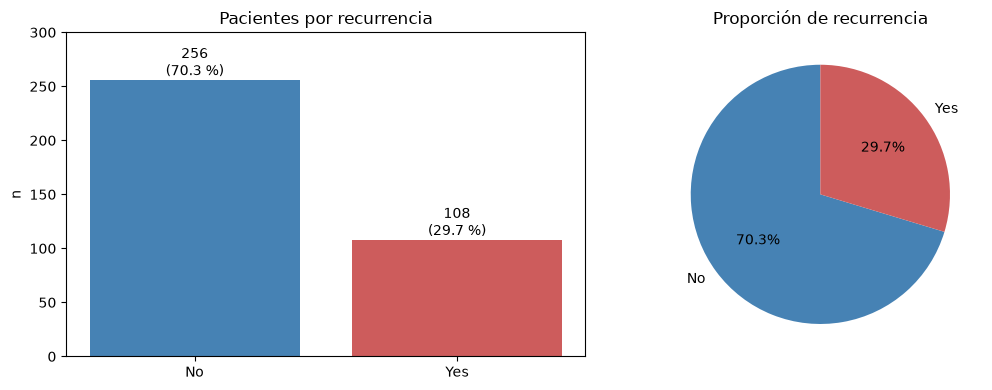

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
conteo = df["Recurred"].value_counts()
axes[0].bar(conteo.index, conteo.values, color=["steelblue", "indianred"])
for i, v in enumerate(conteo.values):
    axes[0].text(i, v, f"{v}\n({100*v/conteo.sum():.1f} %)", ha="center", va="bottom")
axes[0].set_title("Pacientes por recurrencia"); axes[0].set_ylabel("n")
axes[0].set_ylim(0, 300)

axes[1].pie(conteo.values, labels=conteo.index, autopct="%1.1f%%", startangle=90,
            colors=["steelblue", "indianred"])
axes[1].set_title("Proporción de recurrencia")
plt.tight_layout(); plt.show()

**Hallazgo:** 256 pacientes sin recurrencia (70,3 %) y 108 con recurrencia (29,7 %). Hay
desbalance moderado. **Recomendación:** no usar Accuracy como métrica principal (un
modelo que prediga siempre "No" acertaría 70 % sin detectar ni un solo caso) y estratificar
la división; en el modelado se justificará `class_weight="balanced"` para dar más peso a
la clase minoritaria. Recordar que cada fila adicional vale mucho: el dataset es pequeño.

**b) Histograma y boxplot de `Age` según recurrencia.**

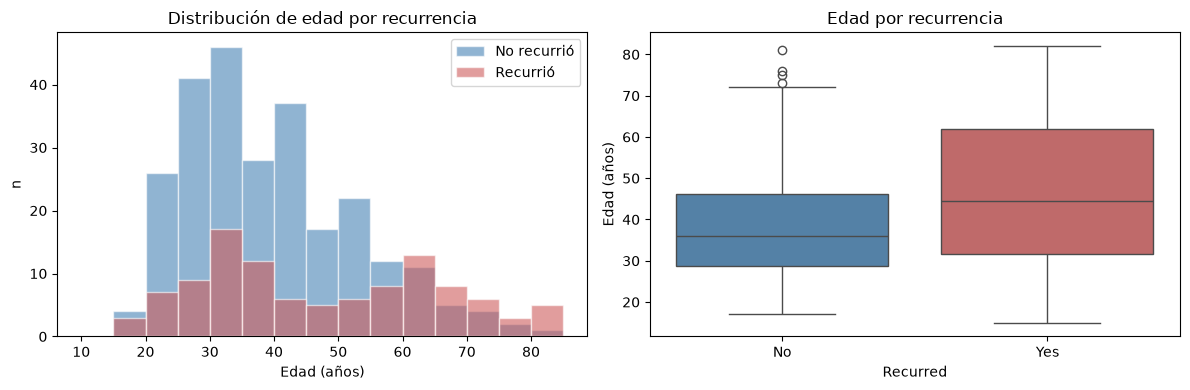

{'No': 36.0, 'Yes': 44.5}
Mediana de edad en recurrentes: 44.5 | en no recurrentes: 36.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(10, 90, 5)
axes[0].hist(df.loc[df["Recurred"] == "No", "Age"], bins=bins, alpha=0.6,
             label="No recurrió", color="steelblue", edgecolor="white")
axes[0].hist(df.loc[df["Recurred"] == "Yes", "Age"], bins=bins, alpha=0.6,
             label="Recurrió", color="indianred", edgecolor="white")
axes[0].set_title("Distribución de edad por recurrencia")
axes[0].set_xlabel("Edad (años)"); axes[0].set_ylabel("n"); axes[0].legend()

sns.boxplot(data=df, x="Recurred", y="Age", hue="Recurred", ax=axes[1],
            palette=["steelblue", "indianred"], legend=False)
axes[1].set_title("Edad por recurrencia"); axes[1].set_xlabel("Recurred"); axes[1].set_ylabel("Edad (años)")
plt.tight_layout(); plt.show()

print(df.groupby("Recurred")["Age"].median().round(1).to_dict())
print("Mediana de edad en recurrentes:", df.loc[df.Recurred=="Yes","Age"].median(),
      "| en no recurrentes:", df.loc[df.Recurred=="No","Age"].median())

**Hallazgo:** la distribución de quienes recurren está desplazada hacia edades mayores
(mediana 44,5 vs. 36,0) y su caja es más alta y ancha. **Recomendación:** mantener `Age`
como variable numérica (no discretizarla) y estandarizarla para que su escala sea
comparable con las binarias en KNN y en la penalización de la regresión logística
(punto 10). En consulta, un paciente de más de 55 años entra en un grupo con mayor
frecuencia observada de recurrencia, lo que apoya seguimiento más estrecho, sin asumir
relación causal.

**c) Dispersión `Age` vs. `Risk_rank` coloreada por recurrencia.**

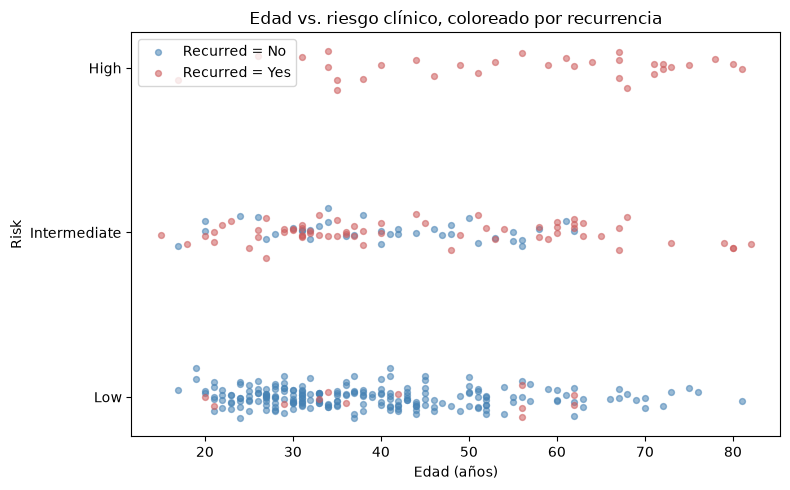

In [13]:
rng = np.random.default_rng(RANDOM_STATE)
jitter = df_eda["Risk_rank"] + rng.normal(0, 0.06, len(df_eda))
fig, ax = plt.subplots(figsize=(8, 5))
for etiqueta, color in [("No", "steelblue"), ("Yes", "indianred")]:
    m = df_eda["Recurred"] == etiqueta
    ax.scatter(df_eda.loc[m, "Age"], jitter[m], s=18, alpha=0.55, color=color, label=f"Recurred = {etiqueta}")
ax.set_yticks([1, 2, 3]); ax.set_yticklabels(["Low", "Intermediate", "High"])
ax.set_xlabel("Edad (años)"); ax.set_ylabel("Risk")
ax.set_title("Edad vs. riesgo clínico, coloreado por recurrencia")
ax.legend(); plt.tight_layout(); plt.show()

**Hallazgo:** los puntos rojos se concentran en el nivel `High` de riesgo (independiente
de la edad) y, dentro de cada nivel, en edades mayores. `High` tiene recurrencia del
100 % (32/32) y `Low` del 5,2 % (12/230). Es una asociación muy fuerte, pero se observa
en pocos pacientes por nivel, por lo que el intervalo de confianza es amplio.


**Recomendación:** `Risk` es una variable clave para el modelo; precisamente por la
diferencia abrupta entre niveles, no debe tratarse como una escala lineal 1-2-3 (punto 9).
Advertencia clínica: que estas tasas describen esta cohorte y no deben usarse como
probabilidades absolutas de otros contextos.

**d) Barras apiladas de `Risk` y `Stage` contra recurrencia.**

Risk
Recurred          No      Yes
Risk                         
High          0.0000 100.0000
Intermediate 37.3000  62.7000
Low          94.8000   5.2000

Stage
Recurred      No      Yes
Stage                    
I        79.3000  20.7000
II       21.9000  78.1000
III       0.0000 100.0000
IVA       0.0000 100.0000
IVB       0.0000 100.0000



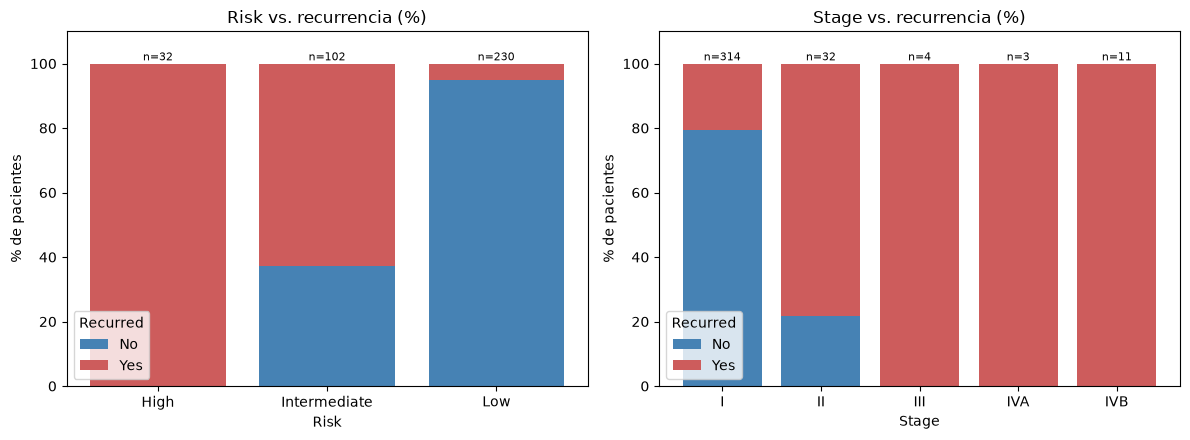

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, var in zip(axes, ["Risk", "Stage"]):
    tabla = pd.crosstab(df[var], df["Recurred"], normalize="index") * 100
    bottom = np.zeros(len(tabla))
    for etiqueta, color in [("No", "steelblue"), ("Yes", "indianred")]:
        ax.bar(tabla.index.astype(str), tabla[etiqueta], bottom=bottom, label=etiqueta, color=color)
        bottom += tabla[etiqueta].values
    for i, n in enumerate(pd.crosstab(df[var], df["Recurred"]).sum(axis=1)):
        ax.text(i, 101, f"n={n}", ha="center", fontsize=8)
    ax.set_title(f"{var} vs. recurrencia (%)"); ax.set_xlabel(var); ax.set_ylabel("% de pacientes")
    ax.set_ylim(0, 110); ax.legend(title="Recurred")
    print(var)
    print((100 * pd.crosstab(df[var], df["Recurred"], normalize="index")).round(1))
    print()
plt.tight_layout(); plt.show()

**Hallazgo:** el gradiente es monotónico y muy marcado. `Risk`: Low 5,2 %, Intermediate
62,7 %, High 100 %. `Stage`: I 20,7 %, II 78,1 %, III/IVA/IVB 100 % (pero III, IVA y IVB
suman solo 18 pacientes). 

**Recomendación:** son las variables con mayor poder
discriminante aparente y el modelo debería aprovecharlas; sin embargo,
con celdas tan pequeñas en los estadios avanzados, cualquier métrica global puede ser
inestable. Se debe reportar el tamaño de cada nivel y evitar conclusiones fuertes sobre
los estadios con n<20; la validación cruzada de la Fase 7 ayudará a medir esa
inestabilidad.

**e) Barras de variables binarias relevantes (`Adenopathy` y `Smoking`).**

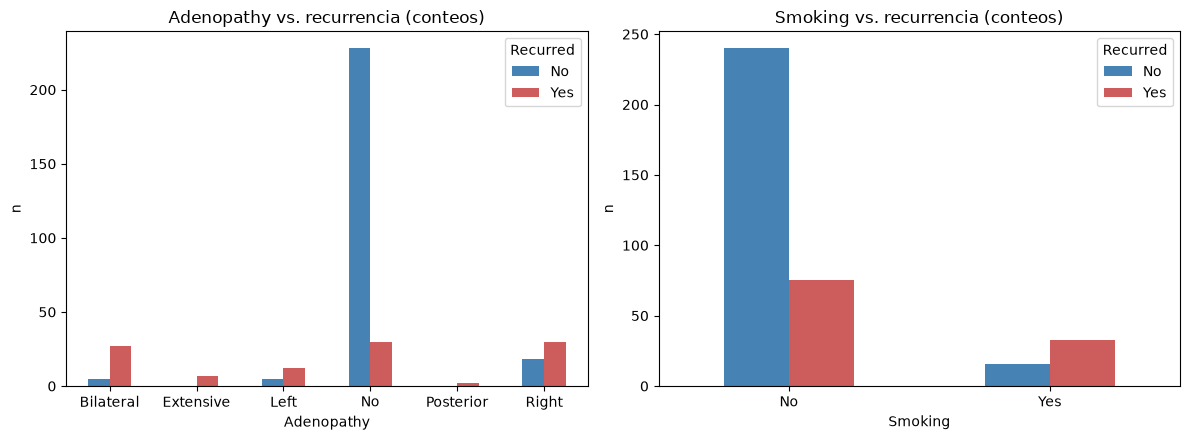

Adenopathy
Recurred        No      Yes
Adenopathy                 
Bilateral  15.6000  84.4000
Extensive   0.0000 100.0000
Left       29.4000  70.6000
No         88.4000  11.6000
Posterior   0.0000 100.0000
Right      37.5000  62.5000

Smoking
Recurred      No     Yes
Smoking                 
No       76.2000 23.8000
Yes      32.7000 67.3000

Focality
Recurred         No     Yes
Focality                   
Multi-Focal 48.5000 51.5000
Uni-Focal   83.3000 16.7000

Pathology
Recurred             No     Yes
Pathology                      
Follicular      57.1000 42.9000
Hurthel cell    70.0000 30.0000
Micropapillary 100.0000  0.0000
Papillary       66.8000 33.2000



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, var in zip(axes, ["Adenopathy", "Smoking"]):
    tabla = pd.crosstab(df[var], df["Recurred"])
    tabla.plot(kind="bar", ax=ax, color=["steelblue", "indianred"], rot=0)
    ax.set_title(f"{var} vs. recurrencia (conteos)")
    ax.set_xlabel(var); ax.set_ylabel("n"); ax.legend(title="Recurred")
plt.tight_layout(); plt.show()

for var in ["Adenopathy", "Smoking", "Focality", "Pathology"]:
    print(var)
    print((100 * pd.crosstab(df[var], df["Recurred"], normalize="index")).round(1))
    print()

**Hallazgo:** la ausencia de adenopatías se asocia a 11,6 % de recurrencia, mientras que
las categorías `Right`, `Left`, `Bilateral`, `Extensive` y `Posterior` superan el 62 %.
El patrón se repite en `Smoking` (67,3 % vs. 23,8 %), `Focality` (Multi-Focal 51,5 % vs.
Uni-Focal 16,7 %) y `Pathology` (Micropapillary 0,0 % vs. Papillary 33,2 %).


**Recomendación:** no seleccionar variables a mano a partir de estas barras; varias
covariables están correlacionadas entre sí (p. ej., N, M y Stage) y la contribución
conjunta la deben estimar los modelos. La regresión logística de la Fase 4 permitirá
comparar signos y magnitudes, y la matriz de confusión dirá si ese aparente poder
discriminante se traduce en Recall útil en validación.

### 9. Codificación de variables categóricas

Cardinalidades reales: 6 variables binarias (`Gender`, `Smoking`, `Hx Smoking`,
`Hx Radiothreapy`, `Focality`, `M`), `Risk` 3, `N` 3, `Pathology` 4, `Thyroid Function` 5,
`Physical Examination` 5, `Stage` 5, `Adenopathy` 6 y `T` 7. Se usa **One-Hot Encoding**
para todas (`handle_unknown="ignore"`, `drop="if_binary"`, salida densa):

- **Variable binaria:** `drop="if_binary"` deja un único indicador 0/1, que es la
  convención vista en clase y evita columnas redundantes.
- **Ordinales clínicas (`Risk`, `T`, `N`, `M`, `Stage`):** sí tienen orden, pero **no
  distancias uniformes ni efecto lineal**. La tabla del punto 8 lo evidencia: pasar de
  `Stage` I a II cambia la recurrencia de 20,7 % a 78,1 %, mientras que III, IVA y IVB
  comparten 100 %. Un único coeficiente ordinal no puede representar ese salto; el
  One-Hot permite un peso por nivel. Para **KNN** es aún más importante: con ordinal, la
  distancia entre `Stage` I y II sería igual que entre III y IV, algo que la clínica no
  respalda.
- **Nominales (`Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology`):**
  no tienen orden; el One-Hot es la única opción que no inventa uno.
- **Cardinalidad manejable:** la matriz resultante tiene 44 columnas de indicadores más
  `Age` = **45 predictoras** para 254 filas de entrenamiento. Es una dimensionalidad alta
  para ese tamaño; en KNN esto diluye las distancias (maldición de la dimensionalidad) y
  favorece a la regresión logística con regularización. Se acepta la codificación porque
  imponer órdenes falsos sería peor, y se deja constancia de que las Fases 3–5 deben
  mirar con lupa el desempeño de KNN.
- **Alternativas descartadas:** *Label Encoding* impone orden falso en las nominales;
  *Binary Encoding* esconde una estructura numérica arbitraria; *Target Encoding* con 364
  filas y 14 categóricas tiene alto riesgo de filtrar el target y exigiría validación
  cruzada interna.

### 10. Escalado de variables numéricas

In [16]:
a = df["Age"]
q1, q3 = a.quantile([0.25, 0.75])
print(f"media = {a.mean():.3f} | desviación = {a.std():.3f} | mediana = {a.median():.3f} | IQR = {q3-q1:.3f}")
print("Límites IQR de Age: [{:.2f}, {:.2f}] | rango observado: [{}, {}]".format(q1-1.5*(q3-q1), q3+1.5*(q3-q1), a.min(), a.max()))
print("Desviación robusta equivalente (IQR/1.349):", round((q3-q1)/1.349, 2))

media = 41.250 | desviación = 15.314 | mediana = 38.000 | IQR = 22.000
Límites IQR de Age: [-3.00, 85.00] | rango observado: [15, 82]
Desviación robusta equivalente (IQR/1.349): 16.31


**Decisión: `StandardScaler` para `Age`.**

- **¿Hace falta escalar?** Sí, y por una razón concreta de KNN: sin escalar, `Age`
  aportaría diferencias de hasta 67 unidades (15–82 años) al cuadrado de la distancia,
  mientras que un indicador One-Hot aporta como máximo 1. La edad dominaría todas las
  distancias y las variables clínicas quedarían casi ignoradas, aunque la edad también
  sea informativa. La regresión logística penalizada también necesita una escala común
  para que la penalización no castigue de forma distinta según las unidades (un año de
  edad no es comparable con un cambio de 0 a 1 en un indicador).
- **¿Por qué `StandardScaler` y no `RobustScaler`?** No hay outliers IQR en `Age`
  (límites [−3, 85], rango 15–82) y su asimetría es moderada (0,68). El escalador robusto
  usa mediana e IQR y sería válido, pero la media y la desviación estándar describen bien
  esta variable y son las que usan los ejemplos de clase para KNN y regresión logística.
- **¿Por qué no Min-Max?** Comprimiría toda la información en [0,1] y cualquier paciente
  futuro fuera del rango de entrenamiento (por ejemplo, 90 años) reescalaría el conjunto;
  no aporta ventajas para estos algoritmos.
- **One-Hot no se escala:** los indicadores ya están en 0/1; escalarlos cambiaría su
  interpretación y no corrige nada. Nota honesta: después del escalado, la varianza de
  `Age` es 1, mientras que un indicador binario con proporción p tiene varianza p(1−p) ≤
  0,25; la edad sigue pesando más en la distancia euclidiana, lo cual es defendible porque
  también es una de las señales más fuertes, pero conviene tenerlo presente al interpretar
  el papel de KNN.

## Fase 2 - División de datos y pipelines

### 11. División estratificada train / validation / test (70/15/15)

**Para qué sirve cada conjunto:** `train` (70 %) estima parámetros y transformaciones;
`validation` (15 %) se usa para comparar modelos, detectar sobreajuste y ajustar
hiperparámetros; `test` (15 %) permanece intocado hasta la Fase 6 y da la estimación
final. No basta con train/test porque cualquier decisión tomada mirando el test lo
convierte en un conjunto de validación encubierto y las métricas finales dejan de ser
honestas.

En un dataset de 364 filas, además, la división debe ser **estratificada**: sin
estratificar es fácil que `val` o `test` queden con 20 % o 40 % de recurrencias y las
métricas oscilen por azar. Con `stratify=y` se conserva la proporción ~29,7 % en los tres
conjuntos.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Recurred", "Response"]).copy()
y = df["Recurred"].map({"No": 0, "Yes": 1}).copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")
print("intersección train∩val:", len(set(X_train.index) & set(X_val.index)),
      "| train∩test:", len(set(X_train.index) & set(X_test.index)),
      "| val∩test:", len(set(X_val.index) & set(X_test.index)))
assert len(X_train) + len(X_val) + len(X_test) == len(df)

# Se comparan únicamente train y validation; test queda reservado hasta la Fase 6.
resumen = pd.DataFrame({
    "n": [len(y_train), len(y_val)],
    "positivos (Yes)": [int(y_train.sum()), int(y_val.sum())],
    "tasa_positivos (%)": [100*y_train.mean(), 100*y_val.mean()],
}, index=["train", "val"])
display(resumen.round(2))

train: (254, 15) | val: (55, 15) | test: (55, 15)
intersección train∩val: 0 | train∩test: 0 | val∩test: 0


,n,positivos (Yes),tasa_positivos (%)
train,254,75,29.5300
val,55,17,30.9100


Las tasas de recurrencia de train y validación quedan en 29,53 % y 30,91 %: la
estratificación funcionó y ambos conjuntos son comparables. Test se reserva sin inspeccionar
hasta la fase 6. Ninguna fila se comparte entre particiones.

### 12. Pipeline de preprocesamiento con `ColumnTransformer`

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ["Age"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

def build_pipeline(model):
    # Pipeline completo (preprocesador + modelo) que reutilizará el modelado.
    return Pipeline([("preprocessor", preprocessor), ("model", model)])

preprocessor.fit(X_train)
print("X_train transformado:", preprocessor.transform(X_train).shape)
print("columnas:", list(preprocessor.get_feature_names_out()))

X_train transformado: (254, 45)
columnas: ['num__Age', 'cat__Gender_M', 'cat__Smoking_Yes', 'cat__Hx Smoking_Yes', 'cat__Hx Radiothreapy_Yes', 'cat__Thyroid Function_Clinical Hyperthyroidism', 'cat__Thyroid Function_Clinical Hypothyroidism', 'cat__Thyroid Function_Euthyroid', 'cat__Thyroid Function_Subclinical Hyperthyroidism', 'cat__Thyroid Function_Subclinical Hypothyroidism', 'cat__Physical Examination_Diffuse goiter', 'cat__Physical Examination_Multinodular goiter', 'cat__Physical Examination_Normal', 'cat__Physical Examination_Single nodular goiter-left', 'cat__Physical Examination_Single nodular goiter-right', 'cat__Adenopathy_Bilateral', 'cat__Adenopathy_Extensive', 'cat__Adenopathy_Left', 'cat__Adenopathy_No', 'cat__Adenopathy_Posterior', 'cat__Adenopathy_Right', 'cat__Pathology_Follicular', 'cat__Pathology_Hurthel cell', 'cat__Pathology_Micropapillary', 'cat__Pathology_Papillary', 'cat__Focality_Uni-Focal', 'cat__Risk_High', 'cat__Risk_Intermediate', 'cat__Risk_Low', 'cat__T_T

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

pipeline_dummy = build_pipeline(DummyClassifier(strategy="most_frequent")).fit(X_train, y_train)
for nombre, XX, yy in [("train", X_train, y_train), ("val", X_val, y_val)]:
    pred = pipeline_dummy.predict(XX)
    print(f"Dummy {nombre:5s} -> Accuracy {accuracy_score(yy, pred):.4f} | "
          f"Precision {precision_score(yy, pred, zero_division=0):.4f} | "
          f"Recall {recall_score(yy, pred, zero_division=0):.4f} | "
          f"F1 {f1_score(yy, pred, zero_division=0):.4f}")

Dummy train -> Accuracy 0.7047 | Precision 0.0000 | Recall 0.0000 | F1 0.0000
Dummy val   -> Accuracy 0.6909 | Precision 0.0000 | Recall 0.0000 | F1 0.0000


El dummy alcanza 70,5 % de Accuracy en train y 69,1 % en validación **con Recall 0**:
nunca detecta una recurrencia. Cualquier modelo útil debe superar ese Recall aunque su
Accuracy sea parecida. Esto justifica que el criterio de selección sea el
Recall de la clase `Yes`, acompañado de Precision y F1.

### 13. Verificación de ausencia de fuga de datos (data leakage)

El `preprocessor` se ajustó una sola vez sobre `X_train`; las particiones de validación y
test solo se transforman dentro de `pipeline.predict()`. Evidencia cuantitativa:

In [20]:
preprocessor.fit(X_train)

num_step = preprocessor.named_transformers_["num"]
scaler = num_step.named_steps["scaler"]
imputer_num = num_step.named_steps["imputer"]
cat_step = preprocessor.named_transformers_["cat"]
encoder = cat_step.named_steps["encoder"]
imputer_cat = cat_step.named_steps["imputer"]

print("Escalador (aprendido en train): mean =", scaler.mean_[0], "| scale =", scaler.scale_[0])
print("  media real en train:", round(X_train["Age"].mean(), 4),
      "| media real en val:", round(X_val["Age"].mean(), 4))
print("Imputador numérico (mediana de train):", imputer_num.statistics_[0])
print("Imputador categórico (moda de train):", dict(zip(categorical_cols, imputer_cat.statistics_)))
print("Categorías aprendidas por columna:", dict(zip(categorical_cols, [len(c) for c in encoder.categories_])))

no_vistos_val = sum(
    int((~X_val[col].isin(encoder.categories_[i])).sum())
    for i, col in enumerate(categorical_cols)
)
print("Valores de val no vistos en train:", no_vistos_val)

Z_train = preprocessor.transform(X_train)
Z_val = preprocessor.transform(X_val)
print("Media de Age escalada -> train:", round(float(Z_train[:, 0].mean()), 6),
      "| val:", round(float(Z_val[:, 0].mean()), 6))

mean_antes = scaler.mean_.copy()
_ = preprocessor.transform(X_val)
print("¿La media del escalador cambió tras transformar val?", not np.array_equal(mean_antes, scaler.mean_))

Escalador (aprendido en train): mean = 41.03543307086614 | scale = 15.528571723538503
  media real en train: 41.0354 | media real en val: 40.3091
Imputador numérico (mediana de train): 37.5
Imputador categórico (moda de train): {'Gender': 'F', 'Smoking': 'No', 'Hx Smoking': 'No', 'Hx Radiothreapy': 'No', 'Thyroid Function': 'Euthyroid', 'Physical Examination': 'Multinodular goiter', 'Adenopathy': 'No', 'Pathology': 'Papillary', 'Focality': 'Uni-Focal', 'Risk': 'Low', 'T': 'T2', 'N': 'N0', 'M': 'M0', 'Stage': 'I'}
Categorías aprendidas por columna: {'Gender': 2, 'Smoking': 2, 'Hx Smoking': 2, 'Hx Radiothreapy': 2, 'Thyroid Function': 5, 'Physical Examination': 5, 'Adenopathy': 6, 'Pathology': 4, 'Focality': 2, 'Risk': 3, 'T': 7, 'N': 3, 'M': 2, 'Stage': 5}
Valores de val no vistos en train: 0
Media de Age escalada -> train: 0.0 | val: -0.046775
¿La media del escalador cambió tras transformar val? False


**Evidencia cuantitativa:**

- El `StandardScaler` guarda `mean_ = 41,0354`, que es exactamente la media de `Age` en
  **train**; la media de validación es 40,3091. La desviación (`scale_ = 15,5286`)
  también corresponde a train.
- La media de `Age` escalada es 0,000000 en train (centrada por construcción) y
  **−0,046775 en validación**, porque la validación se transforma con la media de train y
  no con la suya. Si hubiera fuga, ambos valores serían 0,000000.
- Las 44 categorías One-Hot se aprendieron solo de train; no hay valores de validación
  fuera del vocabulario (0 no vistos) y `handle_unknown="ignore"` cubre ese caso en
  producción.
- El imputador no modifica ninguna fila (no hay NaN), y transformar validación **no cambia
  ningún atributo** del preprocesador: `.transform()` no reajusta.
- La deduplicación se hizo **antes** de dividir, de modo que ninguna fila exacta del
  archivo puede aparecer a la vez en train y test. Las 7 coincidencias de vector clínico
  que persisten (documentadas en el punto 5) son pacientes distintos con desenlaces
  distintos; no son fuga, son ruido irreducible y se analizarán en las conclusiones.

### Datos listos para modelar

| Elemento | Valor |
| --- | --- |
| Dataset limpio | `df` (364 filas, 17 columnas) |
| `X_train`, `y_train` | (254, 15) — 75 positivos (29,53 %) |
| `X_val`, `y_val` | (55, 15) — 17 positivos (30,91 %) |
| `X_test`, `y_test` | (55, 15) — 16 positivos (29,09 %) |
| Target | `y` numérico: `No`→0, `Yes`→1 |
| `numeric_cols` | `["Age"]` |
| `categorical_cols` | `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology`, `Focality`, `Risk`, `T`, `N`, `M`, `Stage` (14) |
| `preprocessor` | `StandardScaler` para `Age`; `OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)` para categóricas. Salida: 45 columnas |
| Utilidad | `build_pipeline(model)` devuelve `Pipeline(preprocessor, model)` ajustable sobre `X_train` |
| Benchmark | `DummyClassifier(strategy="most_frequent")`: Accuracy val 0,6909, Recall val 0,0000 |
| Exclusiones | 19 filas duplicadas exactas (4,96 %); columna `Response` (fuga temporal); target `Recurred` separado como `y` |
| Nota | No hay nulos; los imputadores quedan como salvaguarda. `stratify=y` en ambas divisiones |

**Nota para comparar los modelos base:** los modelos base acordados son
`KNeighborsClassifier(n_neighbors=5, p=2)`, `LogisticRegression(l1_ratio=0.0, solver="liblinear", class_weight="balanced", max_iter=5_000)`
y `LogisticRegression(l1_ratio=1.0, ...)`, todos con `build_pipeline(...)`. En la API fijada,
`l1_ratio=0.0` representa L2 y `l1_ratio=1.0` representa L1. Calcular
Accuracy, Precision, Recall, F1 y matriz de confusión en train y validation
(`pos_label=1`), comparar ambas particiones para diagnosticar sobreajuste y **no tocar
`X_test` hasta la Fase 6**. Con 254 filas de entrenamiento y 45 predictoras One-Hot, la
regularización y el valor de `k` son críticos.

## Fase 4 - Modelado base de clasificación

Se entrenan KNN Classifier y dos regresiones logísticas: L2 (Ridge) y L1 (Lasso).
Cada modelo vive en un `Pipeline` con una copia del preprocesador, ajustado solo con
`X_train`. No se consulta test.

Las logísticas usan `class_weight="balanced"` porque la recurrencia positiva es
minoritaria y un falso negativo puede privar a una paciente de seguimiento oportuno.
Esta decisión busca Recall, aceptando que puede aumentar falsos positivos. KNN queda
como comparación no paramétrica con `k=5` y distancia euclidiana.

In [21]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import time

modelos_clasificacion = {
    "KNN": KNeighborsClassifier(n_neighbors=5, p=2),
    "Logística L2": LogisticRegression(
        l1_ratio=0.0, solver="liblinear", class_weight="balanced",
        max_iter=5_000, random_state=RANDOM_STATE,
    ),
    "Logística L1": LogisticRegression(
        l1_ratio=1.0, solver="liblinear", class_weight="balanced",
        max_iter=5_000, random_state=RANDOM_STATE,
    ),
}

pipelines_clasificacion = {}
predicciones_clasificacion = {}
matrices_confusion = {}
filas_metricas_clf = []

for nombre, estimador in modelos_clasificacion.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", estimador),
    ])
    inicio = time.perf_counter()
    pipeline.fit(X_train, y_train)
    segundos_fit = time.perf_counter() - inicio

    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    pipelines_clasificacion[nombre] = pipeline
    predicciones_clasificacion[nombre] = {"train": pred_train, "val": pred_val}

    fila = {"Modelo": nombre, "seg_fit": segundos_fit}
    for conjunto, y_real, y_pred in [
        ("train", y_train, pred_train), ("val", y_val, pred_val)
    ]:
        fila.update({
            f"Accuracy_{conjunto}": accuracy_score(y_real, y_pred),
            f"Precision_{conjunto}": precision_score(y_real, y_pred, zero_division=0),
            f"Recall_{conjunto}": recall_score(y_real, y_pred, zero_division=0),
            f"F1_{conjunto}": f1_score(y_real, y_pred, zero_division=0),
        })
        matrices_confusion[(nombre, conjunto)] = confusion_matrix(y_real, y_pred)
    filas_metricas_clf.append(fila)

metricas_clasificacion = pd.DataFrame(filas_metricas_clf).set_index("Modelo")
columnas_tabla = [
    "Accuracy_train", "Precision_train", "Recall_train", "F1_train",
    "Accuracy_val", "Precision_val", "Recall_val", "F1_val", "seg_fit",
]
display(metricas_clasificacion[columnas_tabla].round(4))

,Accuracy_train,Precision_train,Recall_train,F1_train,Accuracy_val,Precision_val,Recall_val,F1_val,seg_fit
Modelo,,,,,,,,,
KNN,0.8976,0.8889,0.7467,0.8116,0.8545,0.8462,0.6471,0.7333,0.0123
Logística L2,0.8898,0.7701,0.8933,0.8272,0.8727,0.8125,0.7647,0.7879,0.0134
Logística L1,0.8937,0.7667,0.9200,0.8364,0.8545,0.7647,0.7647,0.7647,0.0128


## Fase 5 - Matrices de confusión y diagnóstico de clasificación

La clase positiva es recurrencia (`1`). En cada matriz, `FN` (abajo a la izquierda)
es una recurrencia real clasificada como no recurrencia; es el error clínicamente
más costoso porque puede retrasar seguimiento. `FP` (arriba a la derecha) implica
vigilancia o pruebas adicionales innecesarias. Por esto se prioriza **Recall**, pero
se revisan Precision y F1 para no generar una cantidad impráctica de alertas.

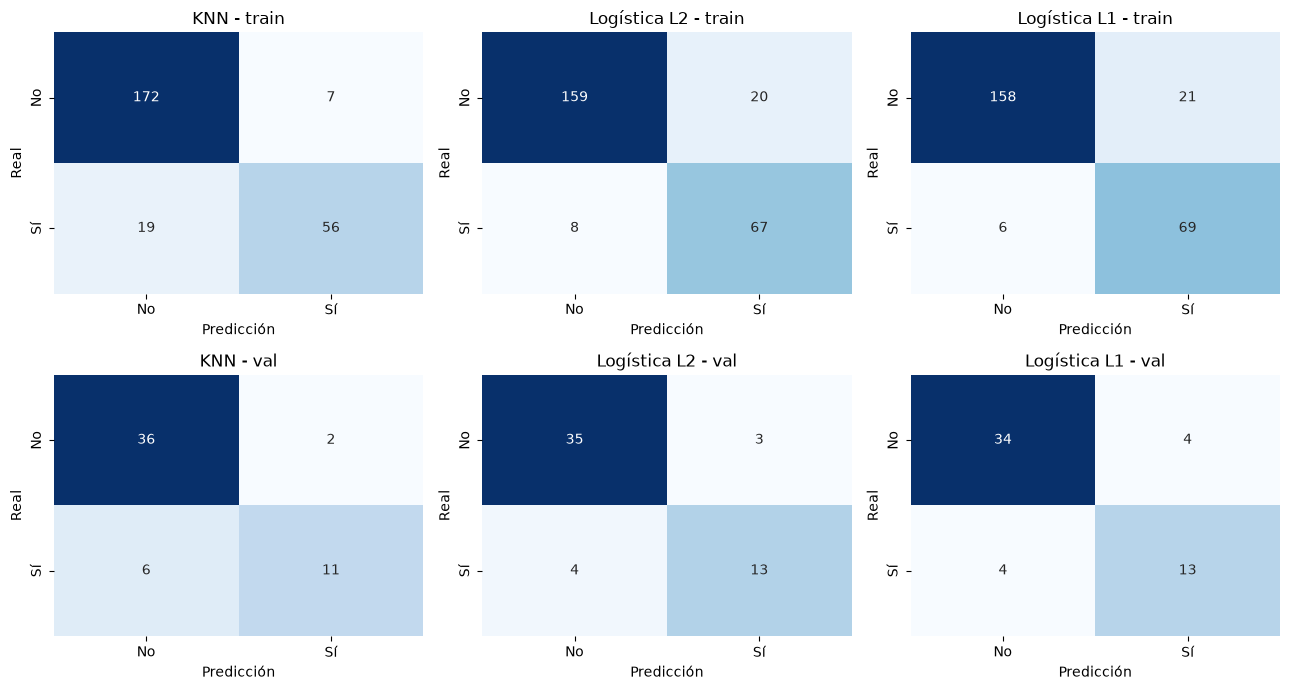

KNN           | val: TN=36, FP=2, FN=6, TP=11
Logística L2  | val: TN=35, FP=3, FN=4, TP=13
Logística L1  | val: TN=34, FP=4, FN=4, TP=13


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for col, nombre in enumerate(modelos_clasificacion):
    for row, conjunto in enumerate(["train", "val"]):
        cm = matrices_confusion[(nombre, conjunto)]
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No", "Sí"], yticklabels=["No", "Sí"],
            ax=axes[row, col],
        )
        axes[row, col].set_title(f"{nombre} - {conjunto}")
        axes[row, col].set_xlabel("Predicción")
        axes[row, col].set_ylabel("Real")
plt.tight_layout()
plt.show()

for nombre in modelos_clasificacion:
    cm = matrices_confusion[(nombre, "val")]
    tn, fp, fn, tp = cm.ravel()
    print(f"{nombre:13s} | val: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

In [23]:
diagnostico_clasificacion = metricas_clasificacion.copy()
diagnostico_clasificacion["brecha_recall"] = (
    diagnostico_clasificacion["Recall_train"]
    - diagnostico_clasificacion["Recall_val"]
)
diagnostico_clasificacion["brecha_F1"] = (
    diagnostico_clasificacion["F1_train"]
    - diagnostico_clasificacion["F1_val"]
)

def diagnosticar_clasificacion(fila):
    if fila["brecha_F1"] > 0.10 or fila["brecha_recall"] > 0.10:
        return "Señal de sobreajuste: caída > 0,10 de train a validación."
    if fila["Recall_train"] < 0.70 and fila["Recall_val"] < 0.70:
        return "Señal de subajuste: Recall bajo en ambos conjuntos."
    return "Generalización estable: brechas train-validation moderadas."

diagnostico_clasificacion["lectura"] = diagnostico_clasificacion.apply(
    diagnosticar_clasificacion, axis=1
)
display(diagnostico_clasificacion[["brecha_recall", "brecha_F1", "lectura"]].round(4))

# Prioridad acordada: Recall de recurrencia; F1 desempata para controlar falsas alertas.
ranking_clasificacion = metricas_clasificacion.assign(
    brecha_abs=lambda d: (d["Recall_train"] - d["Recall_val"]).abs()
).sort_values(
    ["Recall_val", "F1_val", "brecha_abs"], ascending=[False, False, True]
)
modelo_ganador_clasificacion = ranking_clasificacion.index[0]
pipeline_ganador_clasificacion = pipelines_clasificacion[modelo_ganador_clasificacion]
print("Modelo ganador de clasificación:", modelo_ganador_clasificacion)
display(ranking_clasificacion[[
    "Recall_val", "Precision_val", "F1_val", "Accuracy_val", "brecha_abs", "seg_fit"
]].round(4))

,brecha_recall,brecha_F1,lectura
Modelo,,,
KNN,0.0996,0.0783,Generalización estable: brechas train-validati...
Logística L2,0.1286,0.0393,"Señal de sobreajuste: caída > 0,10 de train a ..."
Logística L1,0.1553,0.0717,"Señal de sobreajuste: caída > 0,10 de train a ..."


Modelo ganador de clasificación: Logística L2


,Recall_val,Precision_val,F1_val,Accuracy_val,brecha_abs,seg_fit
Modelo,,,,,,
Logística L2,0.7647,0.8125,0.7879,0.8727,0.1286,0.0134
Logística L1,0.7647,0.7647,0.7647,0.8545,0.1553,0.0128
KNN,0.6471,0.8462,0.7333,0.8545,0.0996,0.0123


### Selección del modelo de clasificación y *trade-offs*

**Se selecciona Regresión Logística L2.** En validación detecta 13 de las 17
recurrencias: Recall **0,7647**, con 4 falsos negativos. Empata en Recall con L1,
pero presenta mejor Precision (**0,8125** vs. 0,7647), mejor F1 (**0,7879** vs.
0,7647), mayor Accuracy (**0,8727** vs. 0,8545) y un falso positivo menos. L2 logra,
por tanto, la misma sensibilidad clínica con menos alertas innecesarias.

KNN tiene la menor brecha train–validation, pero su Recall baja de 0,7467 a
**0,6471**: deja escapar 6 de 17 recurrencias. Esa pérdida clínica pesa más que su
Precision de 0,8462. Las dos logísticas muestran caída de Recall superior a 0,10,
compatible con varianza por el tamaño reducido de la muestra; variar `k` puede mover
a KNN entre sobreajuste y subajuste. L2 cae menos que L1
(0,1286 vs. 0,1553) y regulariza de manera más estable las señales One-Hot
correlacionadas. En las logísticas, `C` controla la fuerza de regularización y deberá
ajustarse mediante validación cruzada. Las métricas no muestran un subajuste generalizado,
aunque superar al dummy por sí solo no bastaría para descartarlo. L2 es el modelo que debe optimizarse por
validación cruzada, priorizando Recall y vigilando Precision/F1.

## Fase 9 - Conclusiones de clasificación (compilación de Persona B)

**Aporte de datos (fases 1–2).** La deduplicación retiró 19 registros y la exclusión de
`Response` evitó usar una señal posterior al momento de predicción. `Age` no presentó
outliers IQR y se estandarizó; las variables clínicas categóricas se conservaron con
One-Hot para no imponer distancias ordinales artificiales. El tamaño final (364 casos),
el 29,7 % de recurrencias y las siete combinaciones clínicas repetidas con desenlaces
distintos obligan a interpretar el resultado con cautela.

**Aporte de modelado (fases 4–5).** En este dataset pequeño y de alta dimensionalidad
One-Hot, KNN sufre la “maldición
de la dimensionalidad”: aun con `Age` estandarizada, su Recall de validación es solo
0,6471. Las logísticas regularizadas producen una frontera más útil. L1 alcanza
Recall 0,7647, pero L2 conserva ese mismo Recall con mejor F1 (0,7879), mejor
Precision (0,8125) y menor brecha respecto a train; distribuir el peso entre señales
clínicas relacionadas resulta más estable que forzar dispersión con el valor inicial
de `C`. Se elige **Logística L2** porque reduce falsos negativos sin generar tantas
alertas falsas como L1. El resultado es educativo, no una herramienta clínica: el
tamaño muestral, el desbalance y la ausencia de validación externa limitan cualquier
generalización.

**Integración con generalización (fases 6–8).** Persona C debe conservar como modelo
seleccionado la **Logística L2**, evaluar los tres modelos una sola vez en test y optimizar
solo L2 mediante validación cruzada sobre train + validation. Al integrar esos resultados,
se debe comparar validación contra test, reportar `best_params_` y reemplazar este aviso
por la conclusión de generalización. La selección base no debe cambiarse mirando test.

El subplot 2×2 siguiente reúne la evidencia disponible de datos y modelado sin consultar
test: balance de clases, edad por recurrencia, matriz de confusión de L2 en validación y
comparación de Precision/Recall/F1 de los tres modelos.

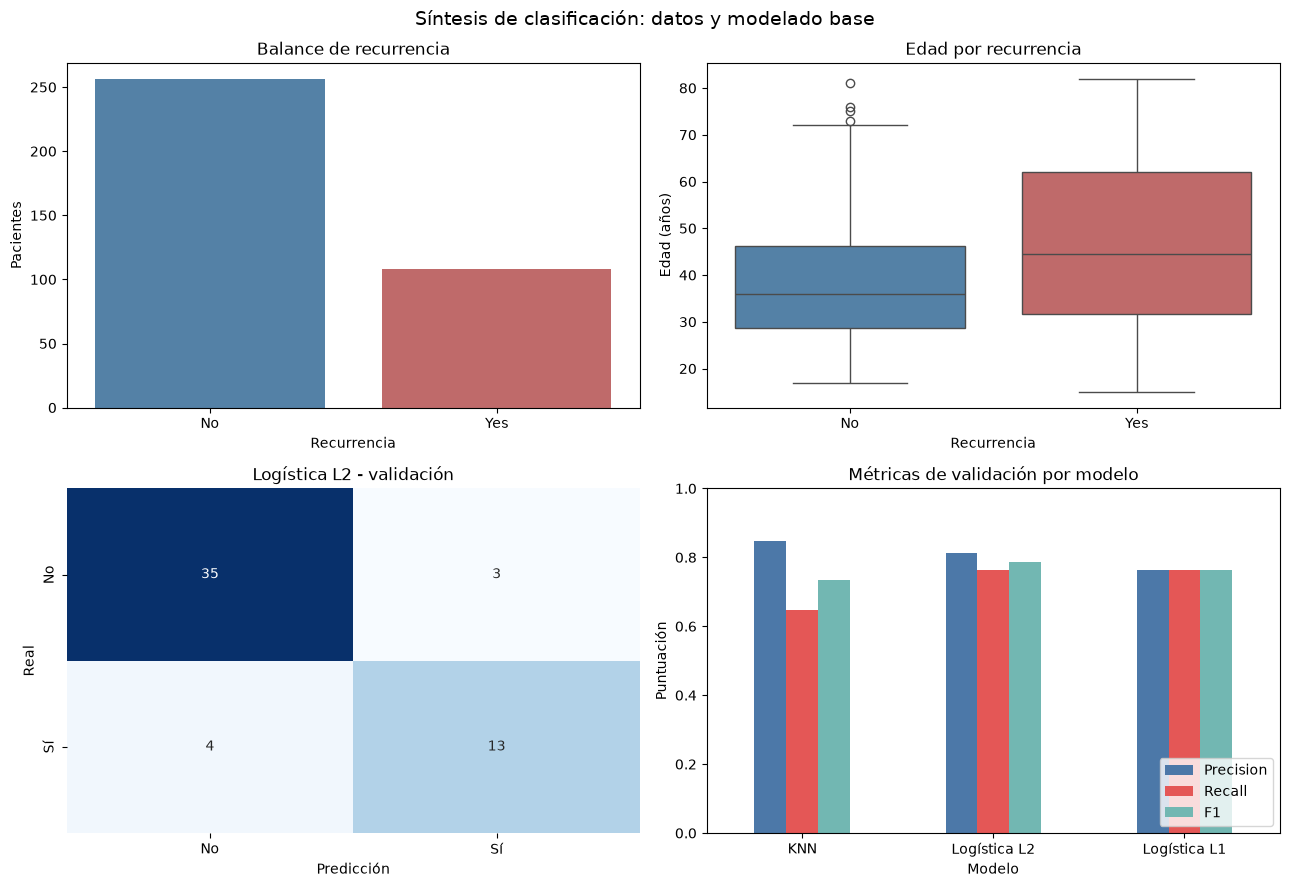

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df, x="Recurred", hue="Recurred", legend=False,
              palette=["steelblue", "indianred"], ax=axes[0, 0])
axes[0, 0].set_title("Balance de recurrencia")
axes[0, 0].set_xlabel("Recurrencia"); axes[0, 0].set_ylabel("Pacientes")

sns.boxplot(data=df, x="Recurred", y="Age", hue="Recurred", legend=False,
            palette=["steelblue", "indianred"], ax=axes[0, 1])
axes[0, 1].set_title("Edad por recurrencia")
axes[0, 1].set_xlabel("Recurrencia"); axes[0, 1].set_ylabel("Edad (años)")

cm_ganador = matrices_confusion[(modelo_ganador_clasificacion, "val")]
sns.heatmap(cm_ganador, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No", "Sí"], yticklabels=["No", "Sí"], ax=axes[1, 0])
axes[1, 0].set_title(f"{modelo_ganador_clasificacion} - validación")
axes[1, 0].set_xlabel("Predicción"); axes[1, 0].set_ylabel("Real")

metricas_clasificacion[["Precision_val", "Recall_val", "F1_val"]].plot(
    kind="bar", ylim=(0, 1), rot=0, ax=axes[1, 1],
    color=["#4c78a8", "#e45756", "#72b7b2"]
)
axes[1, 1].set_title("Métricas de validación por modelo")
axes[1, 1].set_xlabel("Modelo"); axes[1, 1].set_ylabel("Puntuación")
axes[1, 1].legend(["Precision", "Recall", "F1"], loc="lower right")

fig.suptitle("Síntesis de clasificación: datos y modelado base", fontsize=14)
plt.tight_layout(); plt.show()